In [1]:
# !uv run python -m ensurepip --upgrade
# !python -m spacy download en_core_web_sm

In [2]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
import os
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import entropy
from single_sentence import (
    check_roles,
    get_linguistic_stats,
    load_experiments_results,
    map_subwords_to_tokens,
    normalize_lengths,
    perform_ttest,
    plot_attribution_trend,
    plot_dist,
    plot_token_count_distribution,
)
from sklearn.preprocessing import OneHotEncoder

CHARTS_DIR = "figures/single_sentence/"
os.makedirs(CHARTS_DIR, exist_ok=True)

STATS_DIR = "stats/single_sentence/"
os.makedirs(STATS_DIR, exist_ok=True)

# Tests and preparation

## Text

In [4]:
t2s_df = load_experiments_results("T2S")
t2s_df["mode"] = "T2S"

t2t_df = load_experiments_results("T2T")
t2t_df["mode"] = "T2T"

text_df = pd.concat([t2s_df, t2t_df], ignore_index=True)

In [5]:
text_df["count_explainable_tokens"] = text_df["attr_summary"].apply(lambda x: x["count_text_tokens"])
text_df["prompt_text_roles"] = text_df["conversation"].apply(lambda x: x[1][0]["roles"])
text_df["prompt_text"] = text_df["prompt_texts"].apply(lambda x: x[0])
text_df["sv"] = text_df["conversation"].apply(lambda x: x[1][0]["shap_values"])

text_df["raw_model_response"] = text_df["conversation"].apply(lambda x: "".join(x[2][0]["content"]))
text_df["raw_prompt_text"] = text_df["conversation"].apply(lambda x: "".join(x[1][0]["content"]))
text_df["raw_prompt_text_tokens"] = text_df["conversation"].apply(lambda x: x[1][0]["content"])
if not (
    text_df[["prompt_text", "raw_prompt_text"]]
    .apply(lambda row: row["prompt_text"] in row["raw_prompt_text"], axis=1)
    .all()
    .item()
    and text_df[["prompt_text_roles", "sv"]].apply(check_roles, axis=1).all()
).item():
    raise RuntimeError("Prompt text or roles check failed.")

In [6]:
text_df["attr_summary"][0]

{'abs_sum_text': 1.0000000149011612,
 'abs_sum_audio': 0.0,
 'frac_text': 1.0,
 'frac_audio': 0.0,
 'count_text_tokens': 5,
 'count_audio_segments': 0}

In [7]:
def filter_valid_sv(row: pd.Series) -> pd.Series:
    """Filter valid shap values and tokens."""
    sv = np.asarray(row["sv"])
    valid_mask = ~pd.isna(sv)
    tokens = np.asarray(row["raw_prompt_text_tokens"])[valid_mask]
    return pd.Series(
        {
            "sv": sv[valid_mask],
            "tokens": tokens,
            "inputs": "".join(tokens),
            "row_index": row["row_index"],
            "count_explainable_tokens": len(tokens),
            "neyman_steps": row["neyman_steps"],
            "n_calls": row["n_calls"],
            "runtime_sec": row["runtime_sec"],
            "raw_model_response": row["raw_model_response"],
            "mode": row["mode"],
        }
    )


text_df = text_df.apply(filter_valid_sv, axis=1)

text_df.head(5)

,sv,tokens,inputs,row_index,count_explainable_tokens,neyman_steps,n_calls,runtime_sec,raw_model_response,mode
0,"[0.0, 0.3345136046409607, 0.4992281198501587, ...","[Who, developed, Rec, apt, cha]",Who developed Recaptcha,86,5,1,30,26.641608,<|im_start|>assistant\n,T2S
1,"[0.42148149013519287, 0.0, 0.3090362548828125,...","[Who, invented, fantasy, sports]",Who invented fantasy sports,25,4,1,14,13.546469,<|im_start|>assistant\n,T2S
2,"[0.1757783591747284, 0.02463986910879612, 0.0,...","[When, was, the, Aten, eo, de, Manila, U...",When was the Ateneo de Manila University founded,55,9,2,162,219.795633,<|im_start|>assistant\n,T2S
3,"[0.2797272503376007, 0.0, 0.36013635993003845,...","[Who, discovered, infrared, light]",Who discovered infrared light,49,4,1,14,14.584506,<|im_start|>assistant\n,T2S
4,"[0.4825690686702728, 0.0, 0.2785368263721466, ...","[How, does, metabolism, work]",How does metabolism work,39,4,1,14,16.176620,<|im_start|>assistant\n,T2S


## Audio

In [8]:
sm2t_df = load_experiments_results("SM2T")
sm2t_df["mode"] = "SM2T"

sm2s_df = load_experiments_results("SM2S")
sm2s_df["mode"] = "SM2S"

sf2t_df = load_experiments_results("SF2T")
sf2t_df["mode"] = "SF2T"

sf2s_df = load_experiments_results("SF2S")
sf2s_df["mode"] = "SF2S"

audio_df = pd.concat([sm2t_df, sm2s_df, sf2t_df, sf2s_df], ignore_index=True)

In [9]:
audio_df["count_explainable_tokens"] = audio_df["audio_segments"].apply(lambda x: len(x["2"]) if "2" in x else None)
audio_df["inputs"] = audio_df["audio_segments"].apply(
    lambda x: " ".join(y["token"] for y in x["2"]) if "2" in x else None
)
audio_df["tokens"] = audio_df["audio_segments"].apply(lambda x: [y["token"] for y in x["2"]] if "2" in x else None)
audio_df["sv"] = audio_df["audio_segments"].apply(lambda x: [y["shap_value"] for y in x["2"]] if "2" in x else None)
audio_df["raw_model_response"] = audio_df["conversation"].apply(lambda x: "".join(x[2][0]["content"]))

if (audio_df["count_explainable_tokens"] != audio_df["sv"].apply(len)).any().item():
    raise RuntimeError("Audio token count and shap values length mismatch.")
for c in ["inputs", "tokens", "sv"]:
    if audio_df[c].isna().any().item():
        raise RuntimeError(f"Column {c} contains NaN values.")

audio_df = audio_df[
    [
        "row_index",
        "tokens",
        "sv",
        "inputs",
        "count_explainable_tokens",
        "mode",
        "neyman_steps",
        "n_calls",
        "runtime_sec",
        "raw_model_response",
    ]
]

## Combined

In [10]:
df = pd.concat([text_df, audio_df], ignore_index=True)

if df.groupby("row_index").agg({"mode": "count"})["mode"].nunique() != 1:
    raise RuntimeError("Missing data.")

# Data preprocessing

## Data distributions

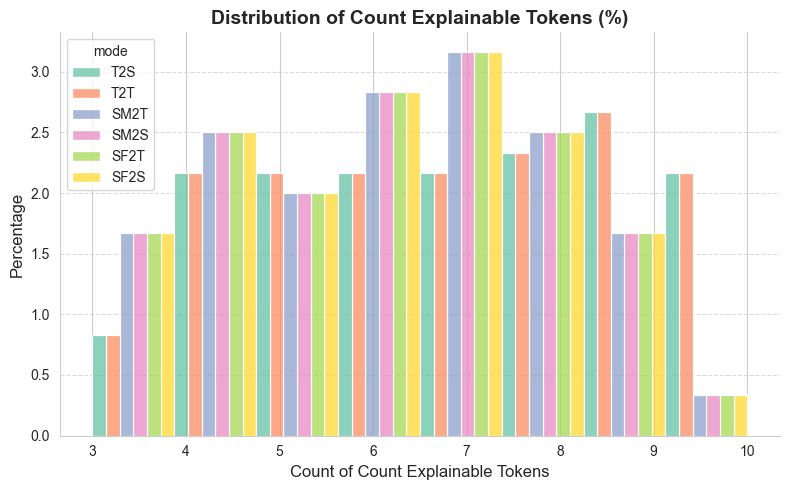

In [11]:
plot_token_count_distribution(df, column="count_explainable_tokens", hue="mode")
plt.savefig(f"{CHARTS_DIR}/token_count_distribution.png")

In [12]:
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

In [13]:
neyman_steps_distribution = df.groupby("mode")["neyman_steps"].value_counts(normalize=True)
neyman_steps_distribution.unstack()

neyman_steps,1,2
mode,,
SF2S,0.37,0.63
SF2T,0.37,0.63
SM2S,0.37,0.63
SM2T,0.37,0.63
T2S,0.31,0.69
T2T,0.31,0.69


In [14]:
summary_stats = df.groupby("mode")[["n_calls", "runtime_sec"]].agg(["describe"])
summary_stats.stack(level=0).unstack(level=1)

describe                                                                 \
        count                mean                    std                 min   
      n_calls runtime_sec n_calls runtime_sec    n_calls runtime_sec n_calls   
mode                                                                           
SF2S    100.0       100.0   59.32   66.081696  53.650737   55.220210     6.0   
SF2T    100.0       100.0   59.84   29.841664  54.003127   25.128298     6.0   
SM2S    100.0       100.0   59.42   67.532749  53.608604   56.420089     6.0   
SM2T    100.0       100.0   59.64   29.651513  53.983447   24.478687     6.0   
T2S     100.0       100.0   84.54  135.972075  68.554398  105.814046     6.0   
T2T     100.0       100.0   84.54   60.645975  68.276239   47.882532     6.0   

                                                                              \
                     25%                 50%                 75%               
     runtime_sec n_calls runtime_sec n_calls runtime_sec n_calls runtime_sec   
mode                                                                           
SF2S    4.747431    14.0   16.182326    30.0   43.425780   118.0  123.527769   
SF2T    2.389576    15.5    6.572411    30.0   21.304932   118.5   52.820496   
SM2S    4.848415    15.5   17.166915    30.0   43.832544   120.0  125.736116   
SM2T    2.411437    14.0    6.459457    30.0   21.220281   118.0   50.577328   
T2S     5.971756    16.0   29.766405    66.0  120.238127   152.5  238.145434   
T2T     2.719613    18.0   13.397068    67.0   52.438374   154.0  102.428912   

                          
         max              
     n_calls runtime_sec  
mode                      
SF2S   200.0  197.016598  
SF2T   200.0   91.336899  
SM2S   202.0  199.532876  
SM2T   202.0   86.893639  
T2S    202.0  327.696372  
T2T    204.0  156.323155

In [15]:
for pt, rmr in df[df["mode"] == "T2T"][["inputs", "raw_model_response"]].head(5).itertuples(index=False):
    print(pt)
    print("\t- " + rmr.replace("\n", "\\n"))

Who developed Recaptcha
	- <|im_start|>assistant\nRecaptcha was developed by **Google**. It was created to help verify that users are human and not bots, which is important for tasks like image recognition, spam filtering, and other security measures.<|im_end|><|im_end|>\n
Who invented fantasy sports
	- <|im_start|>assistant\nFantasy sports, also known as fantasy leagues, were invented by a group of college students in the early 1990s. The concept was first introduced by a group of students at the University of Texas at Austin, led by a group of<|im_end|>\n
When was the Ateneo de Manila University founded
	- <|im_start|>assistant\nThe Ateneo de Manila University was founded in 1909.<|im_end|><|im_end|>\n
Who discovered infrared light
	- <|im_start|>assistant\nThe discovery of infrared light is credited to **Joseph Black**, a Scottish physicist and chemist. In the late 18th century, Black was studying the properties of heat and the behavior of gases. He noticed that when he heated a met

## Enrichment with linguistic features

In [16]:
df["linguistic_stats"] = df["inputs"].apply(get_linguistic_stats)

In [17]:
df["stats_mapping"] = df.apply(
    lambda row: map_subwords_to_tokens(
        row["tokens"],
        [stat["text"] for stat in row["linguistic_stats"]],
    ),
    axis=1,
)

if not (df["stats_mapping"].apply(len) == df["tokens"].apply(len)).all().item():
    raise RuntimeError("Subword to token mapping length mismatch.")

In [18]:
df["stats_matched"] = df.apply(lambda row: [row["linguistic_stats"][i] for i in row["stats_mapping"]], axis=1)
df["deps"] = df["stats_matched"].apply(lambda stats: [stat["dep"] for stat in stats])
df["pos"] = df["stats_matched"].apply(lambda stats: [stat["pos"] for stat in stats])
df["children"] = df["stats_matched"].apply(lambda stats: [stat["children"] for stat in stats])

df.drop(columns=["linguistic_stats", "stats_mapping", "stats_matched"], inplace=True)

In [19]:
exploded_df = (
    df.apply(
        lambda row: [
            {
                "prompt": row["inputs"],
                "row_index": row["row_index"],
                "mode": row["mode"],
                "token": token,
                "id": i,
                "sv": sv,
                "dep": dep,
                "pos": pos,
                "children": children,
            }
            for i, (token, sv, dep, pos, children) in enumerate(
                zip(
                    row["tokens"],
                    row["sv"],
                    row["deps"],
                    row["pos"],
                    row["children"],
                )
            )
        ],
        axis=1,
    )
    .explode()
    .apply(pd.Series)
    .reset_index(drop=True)
)

In [20]:
exploded_df["dep"].unique()

array(['nsubj', 'ROOT', 'dobj', 'compound', 'advmod', 'advcl', 'det',
       'nmod', 'amod', 'aux', 'prep', 'pcomp', 'relcl', 'xcomp', 'attr',
       'pobj', 'auxpass', 'nsubjpass', 'dep', 'dative', 'poss', 'case',
       'punct', 'mark', 'acl', 'agent', 'acomp', 'conj', 'cc', 'appos',
       'npadvmod', 'oprd'], dtype=object)

In [21]:
ROOT_DEP = "ROOT"
SV_COL = "sv"

data = [
    # --- Core meaning (highest importance) ---
    {"dep": ROOT_DEP, "importance": 1, "group": "core_structure"},
    {"dep": "nsubj", "importance": 1, "group": "core_structure"},
    {"dep": "nsubjpass", "importance": 1, "group": "core_structure"},
    {"dep": "dobj", "importance": 1, "group": "core_structure"},
    {"dep": "agent", "importance": 1, "group": "core_structure"},
    # --- Clause structure (very important) ---
    {"dep": "ccomp", "importance": 2, "group": "clausal_structure"},
    {"dep": "xcomp", "importance": 2, "group": "clausal_structure"},
    {"dep": "advcl", "importance": 2, "group": "clausal_structure"},
    {"dep": "relcl", "importance": 2, "group": "clausal_structure"},
    {"dep": "acl", "importance": 2, "group": "clausal_structure"},
    {"dep": "pcomp", "importance": 2, "group": "clausal_structure"},
    # --- Nominal / verbal complements ---
    {"dep": "attr", "importance": 3, "group": "arguments"},
    {"dep": "acomp", "importance": 3, "group": "arguments"},
    {"dep": "dative", "importance": 3, "group": "arguments"},
    {"dep": "pobj", "importance": 3, "group": "arguments"},
    {"dep": "oprd", "importance": 3, "group": "arguments"},
    # --- Modifiers (less critical, descriptive) ---
    {"dep": "amod", "importance": 4, "group": "modifiers"},
    {"dep": "advmod", "importance": 4, "group": "modifiers"},
    {"dep": "npadvmod", "importance": 4, "group": "modifiers"},
    {"dep": "nmod", "importance": 4, "group": "modifiers"},
    {"dep": "compound", "importance": 4, "group": "modifiers"},
    {"dep": "poss", "importance": 4, "group": "modifiers"},
    {"dep": "appos", "importance": 4, "group": "modifiers"},
    # --- Coordination / structure helpers ---
    {"dep": "conj", "importance": 4, "group": "coordination"},
    {"dep": "cc", "importance": 5, "group": "coordination"},
    # --- Function / grammar glue (lowest importance) ---
    {"dep": "det", "importance": 5, "group": "function_words"},
    {"dep": "case", "importance": 5, "group": "function_words"},
    {"dep": "aux", "importance": 5, "group": "function_words"},
    {"dep": "auxpass", "importance": 5, "group": "function_words"},
    {"dep": "mark", "importance": 5, "group": "function_words"},
    {"dep": "prep", "importance": 5, "group": "function_words"},
    {"dep": "punct", "importance": 6, "group": "punctuation"},
    # --- Generic / unknown ---
    {"dep": "dep", "importance": 4, "group": "generic"},
]

dep_importance_df = pd.DataFrame(data)
results_df = exploded_df.join(
    dep_importance_df.set_index("dep"),
    on="dep",
    how="left",
)

In [22]:
results_df.head()

,prompt,row_index,mode,token,id,sv,dep,pos,children,importance,group
0,Who developed Recaptcha,86,T2S,Who,0,0.000000,nsubj,PRON,0,1,core_structure
1,Who developed Recaptcha,86,T2S,developed,1,0.334514,ROOT,VERB,2,1,core_structure
2,Who developed Recaptcha,86,T2S,Rec,2,0.499228,dobj,PROPN,0,1,core_structure
3,Who developed Recaptcha,86,T2S,apt,3,0.125077,ROOT,VERB,2,1,core_structure
4,Who developed Recaptcha,86,T2S,cha,4,0.041181,dobj,PROPN,0,1,core_structure


In [23]:
results_df["S2S"] = results_df["mode"].isin(["SM2S", "SF2S"])
results_df["S2T"] = results_df["mode"].isin(["SM2T", "SF2T"])
results_df["S2*"] = results_df["S2T"] | results_df["S2S"]
results_df["T2*"] = results_df["mode"].isin(["T2T", "T2S"])
results_df["*2T"] = results_df["S2T"] | (results_df["mode"] == "T2T")
results_df["*2S"] = results_df["S2S"] | (results_df["mode"] == "T2S")

additional_modes = ["S2S", "S2T", "S2*", "T2*", "*2T", "*2S"]
modes_order = ["ALL", "T2*", "S2*", "*2T", "*2S", "T2T", "T2S", "S2T", "SF2T", "SM2T", "S2S", "SF2S", "SM2S"]

In [24]:
all_df = results_df.copy()
all_df["mode"] = "ALL"

for k in additional_modes:
    k_df = results_df[results_df[k]].copy()
    k_df["mode"] = k
    all_df = pd.concat([all_df, k_df], ignore_index=True)

all_modes_results_df = pd.concat([results_df, all_df], ignore_index=True)
all_modes_results_df.drop(columns=["S2S", "S2T", "S2*", "T2*", "*2T", "*2S"], inplace=True)

In [25]:
combined_df = df.copy()

combined_df["S2S"] = combined_df["mode"].isin(["SM2S", "SF2S"])
combined_df["S2T"] = combined_df["mode"].isin(["SM2T", "SF2T"])
combined_df["S2*"] = combined_df["S2T"] | combined_df["S2S"]
combined_df["T2*"] = combined_df["mode"].isin(["T2T", "T2S"])
combined_df["*2T"] = combined_df["S2T"] | (combined_df["mode"] == "T2T")
combined_df["*2S"] = combined_df["S2S"] | (combined_df["mode"] == "T2S")

In [26]:
all_df = combined_df.copy()
all_df["mode"] = "ALL"

for k in additional_modes:
    k_df = combined_df[combined_df[k]].copy()
    k_df["mode"] = k
    all_df = pd.concat([all_df, k_df], ignore_index=True)

all_modes_combined_df = pd.concat([combined_df, all_df], ignore_index=True)
all_modes_combined_df.drop(columns=["S2S", "S2T", "S2*", "T2*", "*2T", "*2S"], inplace=True)

In [27]:
all_modes_results_df["mode"] = pd.Categorical(all_modes_results_df["mode"], categories=modes_order, ordered=True)
combined_df["mode"] = pd.Categorical(combined_df["mode"], categories=modes_order, ordered=True)
all_modes_combined_df["mode"] = pd.Categorical(all_modes_combined_df["mode"], categories=modes_order, ordered=True)

# Analysis

## Base

Does token with highest Shapley value correspond to one with highest number of children in dependency parse tree?

In [28]:
def get_match_max(_df, col="children") -> pd.Series:
    """Get match max series."""
    if isinstance(_df, pd.DataFrame):
        _df = _df.groupby("row_index")

    return _df.apply(
        lambda g: int(
            np.intersect1d(
                np.where(g[SV_COL] == g[SV_COL].max())[0],
                np.where(g[col] == g[col].max())[0],
            ).size
            > 0
        )
    )


grouped = results_df.groupby(["mode", "row_index"])
match_max_series = get_match_max(grouped)
summary_match = match_max_series.groupby("mode").mean().to_frame(name="yes_percentage")

for group in additional_modes:
    summary_match.loc[group] = get_match_max(results_df[results_df[group]]).mean()
summary_match.loc["TOTAL_AVERAGE"] = match_max_series.mean()

summary_match.to_csv(f"{STATS_DIR}/summary_match.csv")
summary_match

,yes_percentage
mode,
SF2S,0.260
SF2T,0.370
SM2S,0.350
SM2T,0.340
T2S,0.220
T2T,0.290
S2S,0.360
S2T,0.390
S2*,0.380


Does token with highest Shapley value correspond to ROOT token in dependency parse tree?

In [29]:
def get_match_root(_df) -> pd.Series:
    """Get match root series."""
    if isinstance(_df, pd.DataFrame):
        _df = _df.groupby("row_index")

    return _df.apply(
        lambda g: int(
            np.intersect1d(
                np.where(g[SV_COL] == g[SV_COL].max())[0],
                np.where(g["dep"] == ROOT_DEP)[0],
            ).size
            > 0
        )
    )


match_root_series = get_match_root(results_df.groupby(["mode", "row_index"]))
summary_root = match_root_series.groupby("mode").mean().to_frame(name="root_match_percentage")

for group in additional_modes:
    summary_root.loc[group] = get_match_root(results_df[results_df[group]]).mean()
summary_root.loc["TOTAL_AVERAGE"] = match_root_series.mean()

summary_root.to_csv(f"{STATS_DIR}/summary_root.csv")
summary_root

,root_match_percentage
mode,
SF2S,0.200000
SF2T,0.270000
SM2S,0.240000
SM2T,0.250000
T2S,0.140000
T2T,0.140000
S2S,0.260000
S2T,0.290000
S2*,0.280000


Does most important pos distribution differ by mode?

In [30]:
all_results = pd.DataFrame()
for pos in all_modes_results_df["pos"].unique():
    try:
        r = perform_ttest(
            (
                all_modes_results_df[all_modes_results_df["pos"] == pos]
                .groupby(["row_index", "mode"])["sv"]
                .mean()
                .unstack(level="mode")
            )
        )
    except Exception as e:  # pylint: disable=broad-exception-caught
        print(f"Error processing pos {pos}: {e}")
        continue

    r = r.reset_index()
    r["pos"] = pos
    all_results = pd.concat([all_results, r], ignore_index=True)

Error processing pos NUM: Expected numeric dtype, got object instead.
Error processing pos SYM: Expected numeric dtype, got object instead.


In [31]:
all_results["Degrees_of_Freedom"].describe()

count    522.000000
mean      37.521073
std       20.250555
min        3.000000
25%       32.000000
50%       39.000000
75%       52.000000
max       78.000000
Name: Degrees_of_Freedom, dtype: float64

In [32]:
all_results.to_csv(f"{STATS_DIR}/ttest_pos_by_mode.csv", index=False)

In [33]:
all_results = all_results[all_results["Significant_Adj"]].reset_index(drop=True)
all_results[all_results["Mode_1"].isin(["T2*", "S2*"])].sort_values(["Mode_1", "Mode_2"])["pos"].value_counts()

pos
DET      9
AUX      8
PROPN    4
ADP      4
Name: count, dtype: int64

## Linguistic importance

Does linguistic importance correspond to higher Shapley values?

In [34]:
def get_stats(src_df: pd.DataFrame) -> pd.DataFrame:
    """Get statistics for importance groups."""
    return src_df.groupby("importance")[SV_COL].agg(["mean", "std"]).sort_values(by="mean", ascending=False)


mode_groups = {name: get_stats(group) for name, group in results_df.groupby("mode")}

slices = {
    "TOTAL_AVERAGE": results_df,
}
for k in additional_modes:
    slices[k] = results_df[results_df[k]]

for label, df_slice in slices.items():
    mode_groups[label] = get_stats(df_slice)

combined_importance_stats = pd.concat(mode_groups, names=["mode", "importance"])
combined_importance_stats = combined_importance_stats.sort_values(by=["mode", "mean"], ascending=False)

combined_importance_stats.to_csv(f"{STATS_DIR}/combined_importance_stats.csv")
combined_importance_stats

mean       std
mode          importance                    
TOTAL_AVERAGE 1           0.178835  0.145147
              6           0.167956  0.118814
              2           0.160406  0.121786
              3           0.158810  0.129009
              4           0.143603  0.128471
...                            ...       ...
*2S           1           0.172773  0.138491
              3           0.149968  0.125530
              2           0.148123  0.126293
              4           0.146912  0.127750
              5           0.137328  0.122790

[78 rows x 2 columns]

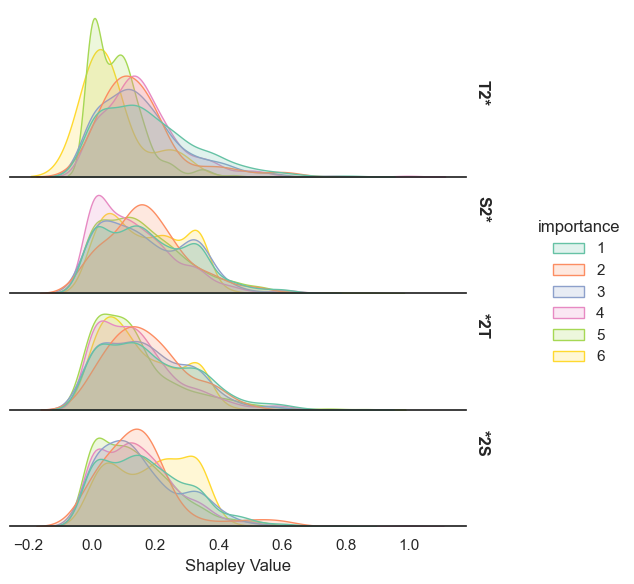

In [35]:
plot_dist(df=all_modes_results_df, hue_col="importance", modes=["T2*", "S2*", "*2T", "*2S"], hspace=-0.3)
plt.savefig(f"{CHARTS_DIR}/shapley_value_vs_importance_distributions_1.png")

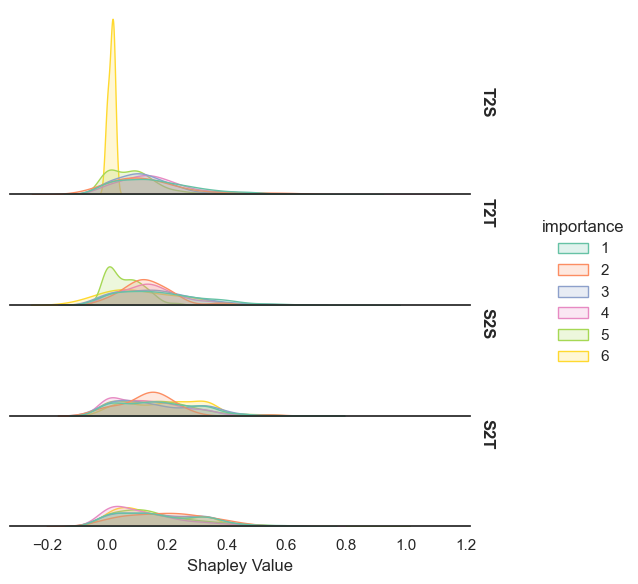

In [36]:
plot_dist(df=all_modes_results_df, hue_col="importance", modes=["T2S", "T2T", "S2S", "S2T"])
plt.savefig(f"{CHARTS_DIR}/shapley_value_vs_importance_distributions_2.png")

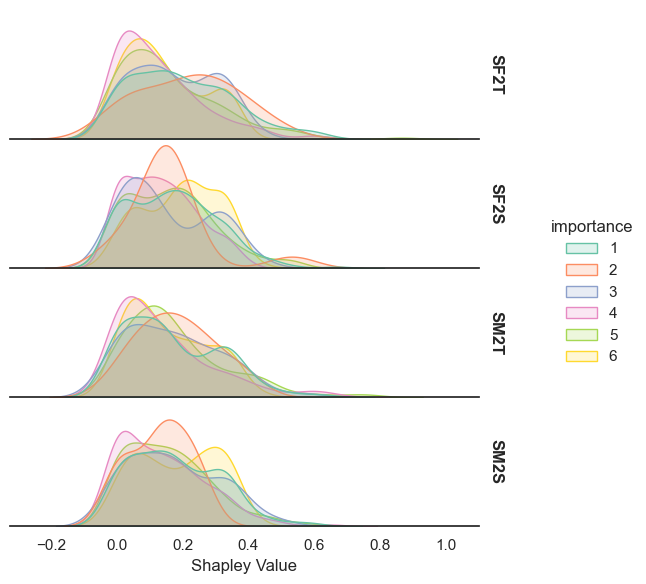

In [37]:
plot_dist(df=all_modes_results_df, hue_col="importance", modes=["SF2T", "SF2S", "SM2T", "SM2S"], hspace=0.0)
plt.savefig(f"{CHARTS_DIR}/shapley_value_vs_importance_distributions_3.png")

In [38]:
corr = (
    (all_modes_results_df.groupby("mode").apply(lambda x: x[["importance", SV_COL]].corr().iloc[0, 1]))
    .to_frame(name="corr_importance_sv")
    .sort_index()
)

corr.to_csv(f"{STATS_DIR}/correlation_importance_sv.csv")
corr

,corr_importance_sv
mode,
ALL,-0.101109
T2*,-0.239804
S2*,-0.050093
*2T,-0.142575
*2S,-0.056739
T2T,-0.302607
T2S,-0.177675
S2T,-0.085581
SF2T,-0.147470


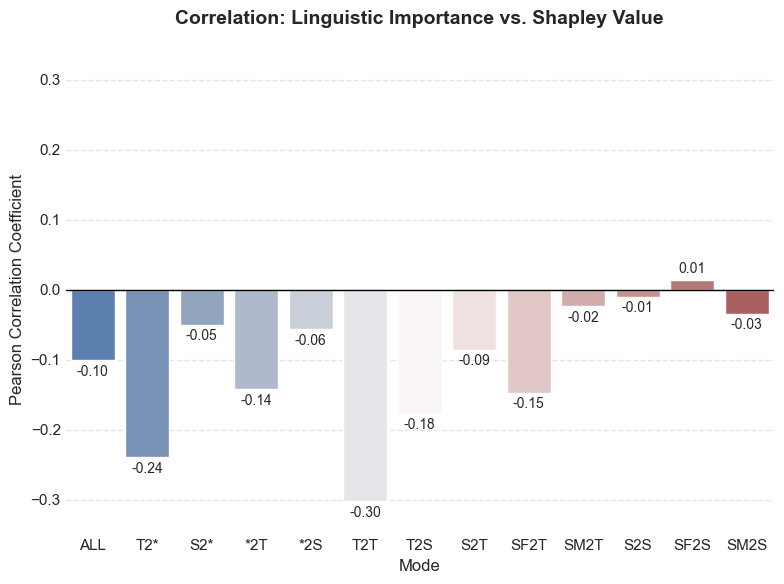

In [39]:
plot_data = corr.reset_index()

plt.figure(figsize=(8, 6))

ax = sns.barplot(data=plot_data, x="mode", y="corr_importance_sv", palette="vlag", edgecolor=None)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=10)

plt.title("Correlation: Linguistic Importance vs. Shapley Value", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Mode", fontsize=12)
plt.ylabel("Pearson Correlation Coefficient", fontsize=12)
plt.ylim(-0.35, 0.35)
plt.axhline(0, color="black", linewidth=1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
sns.despine(left=True, bottom=True, top=True, right=True)
ax.tick_params(axis="both", which="both", length=0)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/correlation_importance_sv_barplot.png")
plt.show()

Does the mean values of Shapley values differ significantly between different linguistic importance groups?

In [40]:
results = perform_ttest(
    (all_modes_results_df.groupby(["row_index", "mode", "importance"])[SV_COL].mean().unstack(level="mode"))
)

results.to_csv(f"{STATS_DIR}/mean_importance_ttest_results.csv")

In [41]:
results = results.reset_index()[["Mode_1", "Mode_2", "P_Value", "Significant_Adj"]]

In [42]:
restrict_to = ["T2T", "S2T", "T2S", "S2S"]
results[results["Mode_1"].isin(restrict_to) & results["Mode_2"].isin(restrict_to)]

,Mode_1,Mode_2,P_Value,Significant_Adj
18,T2T,T2S,0.62,False
19,T2T,S2T,<0.01,True
22,T2T,S2S,<0.01,False
25,T2S,S2T,<0.01,False
28,T2S,S2S,0.03,False
31,S2T,S2S,1.0,False


In [43]:
restrict_to = ["T2*", "S2*", "*2T", "*2S"]
results[results["Mode_1"].isin(restrict_to) & results["Mode_2"].isin(restrict_to)]

,Mode_1,Mode_2,P_Value,Significant_Adj
0,T2*,S2*,<0.01,True
9,*2T,*2S,0.82,False


Does the max values of Shapley values differ significantly between different linguistic importance groups?

In [44]:
results = perform_ttest(
    (all_modes_results_df.groupby(["row_index", "mode", "importance"])[SV_COL].max().unstack(level="mode"))
)

results.to_csv(f"{STATS_DIR}/max_importance_ttest_results.csv")

In [45]:
results = results.reset_index()[["Mode_1", "Mode_2", "P_Value", "Significant_Adj"]]

In [46]:
restrict_to = ["T2T", "S2T", "T2S", "S2S"]
results[results["Mode_1"].isin(restrict_to) & results["Mode_2"].isin(restrict_to)]

,Mode_1,Mode_2,P_Value,Significant_Adj
18,T2T,T2S,0.94,False
19,T2T,S2T,<0.01,True
22,T2T,S2S,<0.01,True
25,T2S,S2T,<0.01,True
28,T2S,S2S,<0.01,True
31,S2T,S2S,0.6,False


## Linguistic group

Similar analysis for linguistic group.

In [47]:
combined_group_stats = (
    all_modes_results_df.groupby(["mode", "group"])[SV_COL]
    .agg(["mean", "std"])
    .sort_values(by=["mode", "mean"], ascending=[True, False])
)

combined_group_stats.to_csv(f"{STATS_DIR}/combined_group_stats.csv")
combined_group_stats

mean       std
mode group                                
ALL  core_structure     0.178835  0.145147
     punctuation        0.167956  0.118814
     clausal_structure  0.160406  0.121786
     arguments          0.158810  0.129009
     modifiers          0.145891  0.129466
...                          ...       ...
SM2S function_words     0.156196  0.129998
     modifiers          0.139151  0.131716
     coordination       0.130157  0.077982
     clausal_structure  0.128345  0.089826
     generic            0.053706  0.075951

[104 rows x 2 columns]

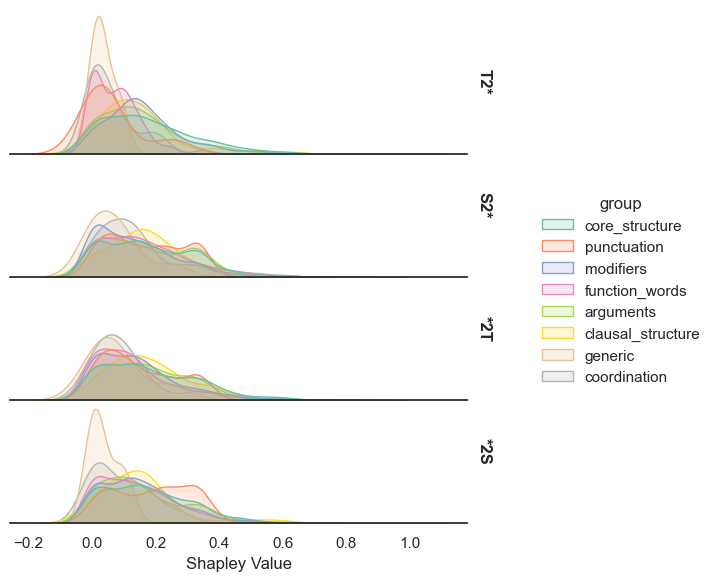

In [48]:
plot_dist(df=all_modes_results_df, hue_col="group", modes=["T2*", "S2*", "*2T", "*2S"], hspace=-0.15)
plt.savefig(f"{CHARTS_DIR}/shapley_value_vs_group_distributions_1.png")

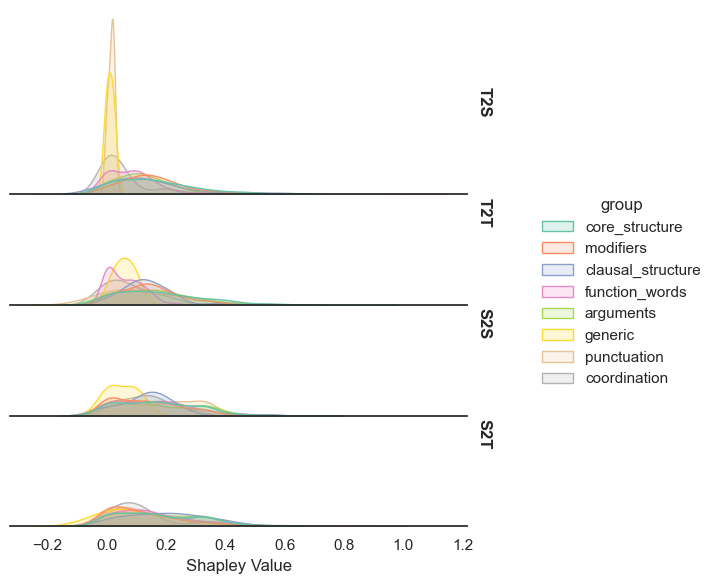

In [49]:
plot_dist(df=all_modes_results_df, hue_col="group", modes=["T2S", "T2T", "S2S", "S2T"])
plt.savefig(f"{CHARTS_DIR}/shapley_value_vs_group_distributions_2.png")

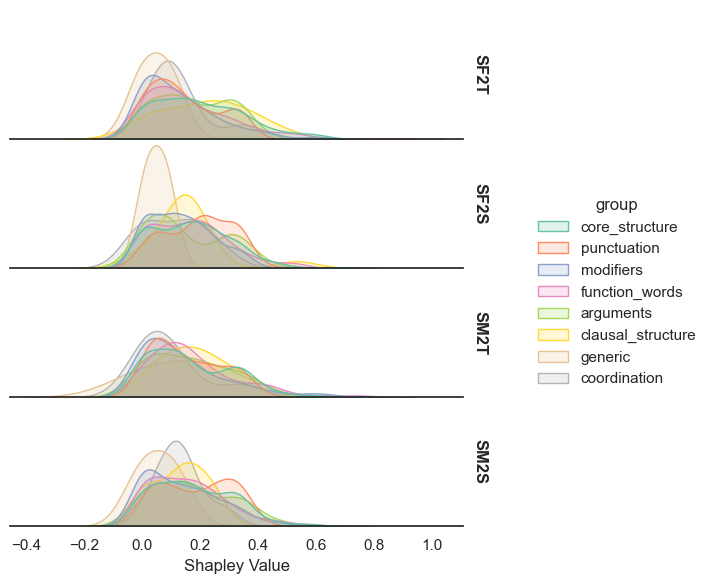

In [50]:
plot_dist(df=all_modes_results_df, hue_col="group", modes=["SF2T", "SF2S", "SM2T", "SM2S"], hspace=0.0)
plt.savefig(f"{CHARTS_DIR}/shapley_value_vs_group_distributions_3.png")

In [51]:
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
encoded_df = encoder.fit_transform(all_modes_results_df[["group"]])

encoded_df.columns = [c.replace("group_", "") for c in encoded_df.columns]
group_cols = list(encoded_df.columns)

full_df = pd.concat([encoded_df, all_modes_results_df[[SV_COL, "mode"]].reset_index(drop=True)], axis=1)

correlation_summary = pd.DataFrame()

for mode in modes_order:
    mode_data = full_df[full_df["mode"] == mode]
    corr_series = mode_data[group_cols + [SV_COL]].corr()[SV_COL]
    correlation_summary[mode] = corr_series.drop(SV_COL)

correlation_summary.to_csv(f"{STATS_DIR}/correlation_groups_sv.csv")
correlation_summary

,ALL,T2*,S2*,*2T,*2S,T2T,T2S,S2T,SF2T,SM2T,S2S,SF2S,SM2S
arguments,0.005668,0.006957,0.011813,0.026399,-0.016573,0.046702,-0.032367,0.020957,0.023477,0.018444,0.001599,-0.019443,0.021701
clausal_structure,0.004653,-0.000392,0.009703,0.018621,-0.010331,-0.012708,0.011792,0.038769,0.057138,0.020444,-0.022859,-0.004872,-0.040053
coordination,-0.052221,-0.077418,-0.037014,-0.047817,-0.057015,-0.064596,-0.090106,-0.038220,-0.026107,-0.050305,-0.035790,-0.045357,-0.026669
core_structure,0.110454,0.186480,0.075404,0.135720,0.083481,0.237369,0.136135,0.089259,0.149422,0.029237,0.060129,0.043331,0.076208
function_words,-0.081187,-0.265604,0.011323,-0.087914,-0.074073,-0.322542,-0.209279,0.023828,-0.009017,0.056595,-0.002661,0.023472,-0.027627
generic,-0.040213,-0.045269,-0.037995,-0.029924,-0.051307,-0.035484,-0.054952,-0.027559,-0.046088,-0.009073,-0.049830,-0.052138,-0.047650
modifiers,-0.043914,0.070250,-0.105841,-0.056860,-0.030077,0.033800,0.106316,-0.102821,-0.128941,-0.076762,-0.109595,-0.122286,-0.097527
punctuation,0.026287,-0.041017,0.021007,-0.018819,0.074727,-0.016321,-0.065452,-0.038249,-0.054802,-0.021734,0.087527,0.105010,0.070870


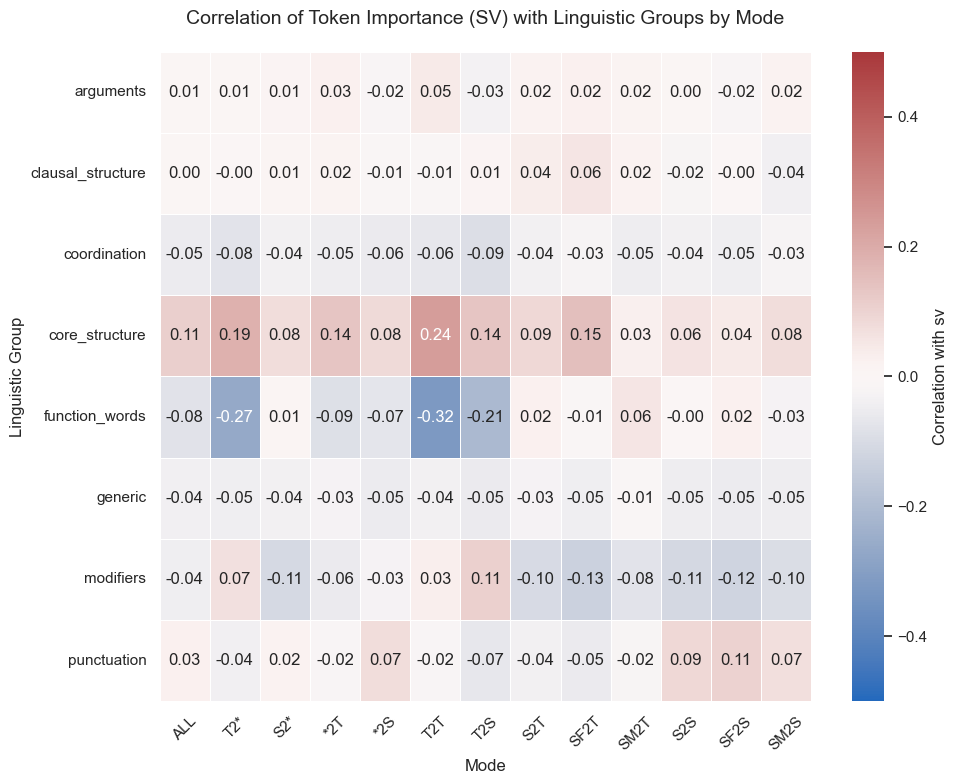

In [52]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_summary,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-0.5,
    vmax=0.5,
    linewidths=0.5,
    cbar_kws={"label": f"Correlation with {SV_COL}"},
)

plt.title("Correlation of Token Importance (SV) with Linguistic Groups by Mode", fontsize=14, pad=20)
plt.ylabel("Linguistic Group")
plt.xlabel("Mode")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/correlation_summary_heatmap.png")
plt.show()

Does the mean values of Shapley values differ significantly between different linguistic groups?

In [53]:
results = perform_ttest(
    (all_modes_results_df.groupby(["row_index", "mode", "group"])[SV_COL].mean().unstack(level="mode"))
)

results.to_csv(f"{STATS_DIR}/mean_group_ttest_results.csv")

In [54]:
results = results.reset_index()[["Mode_1", "Mode_2", "P_Value", "Significant_Adj"]]

In [55]:
restrict_to = ["T2T", "S2T", "T2S", "S2S"]
results[results["Mode_1"].isin(restrict_to) & results["Mode_2"].isin(restrict_to)]

,Mode_1,Mode_2,P_Value,Significant_Adj
18,T2T,T2S,0.62,False
19,T2T,S2T,<0.01,True
22,T2T,S2S,<0.01,False
25,T2S,S2T,<0.01,False
28,T2S,S2S,0.03,False
31,S2T,S2S,0.96,False


In [56]:
restrict_to = ["T2*", "S2*", "*2T", "*2S"]
results[results["Mode_1"].isin(restrict_to) & results["Mode_2"].isin(restrict_to)]

,Mode_1,Mode_2,P_Value,Significant_Adj
0,T2*,S2*,<0.01,True
9,*2T,*2S,0.79,False


Does the max values of Shapley values differ significantly between different linguistic groups?

In [57]:
results = perform_ttest(
    (all_modes_results_df.groupby(["row_index", "mode", "group"])[SV_COL].max().unstack(level="mode"))
)

results.to_csv(f"{STATS_DIR}/max_group_ttest_results.csv")

In [58]:
results = results.reset_index()[["Mode_1", "Mode_2", "P_Value", "Significant_Adj"]]

In [59]:
restrict_to = ["T2T", "S2T", "T2S", "S2S"]
results[results["Mode_1"].isin(restrict_to) & results["Mode_2"].isin(restrict_to)]

,Mode_1,Mode_2,P_Value,Significant_Adj
18,T2T,T2S,0.97,False
19,T2T,S2T,<0.01,True
22,T2T,S2S,<0.01,True
25,T2S,S2T,<0.01,True
28,T2S,S2S,<0.01,True
31,S2T,S2S,0.57,False


## Cumulative sum

Let's also have a look on how the cumulative sum curves look like for all samples.

In [60]:
combined_df["sv_cumsum"] = combined_df[SV_COL].apply(np.cumsum)
cumsums = combined_df.groupby("row_index", group_keys=False)[["mode", "row_index", "sv_cumsum"]].apply(
    normalize_lengths
)

In [61]:
plot_df = cumsums.explode("sv_cumsum").reset_index(drop=True)
plot_df["time (tokens)"] = plot_df.groupby(["mode", "row_index"]).cumcount()

plot_df["sv_cumsum"] = plot_df["sv_cumsum"].astype(float)
plot_df["sv_derivative"] = plot_df.groupby(["mode", "row_index"])["sv_cumsum"].diff().fillna(0)

In [62]:
def plot_importance_cumsum_and_derivative(
    df_: pd.DataFrame, errorbar: Any = ("ci", 95), alpha: float = 0.3, **kw
) -> None:
    """Plot importance cumulative sum and derivative."""
    _, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

    # Top Plot
    sns.lineplot(
        data=df_,
        x="time (tokens)",
        y="sv_cumsum",
        hue="mode",
        alpha=alpha,
        legend="brief",
        ax=ax1,
        palette="Set2",
        errorbar=errorbar,
        **kw,
    )
    ax1.set_ylabel("Cumulative Sum")

    # Bottom Plot
    sns.lineplot(
        data=df_,
        x="time (tokens)",
        y="sv_derivative",
        hue="mode",
        alpha=alpha,
        legend=False,
        ax=ax2,
        palette="Set2",
        errorbar=errorbar,
        **kw,
    )
    ax2.set_ylabel("Derivative")

    leg = ax1.legend(bbox_to_anchor=(0.96, 1), loc="upper left", frameon=True, facecolor="white")
    for lh in leg.legend_handles:
        lh.set_alpha(1)

    sns.despine()
    plt.tight_layout()

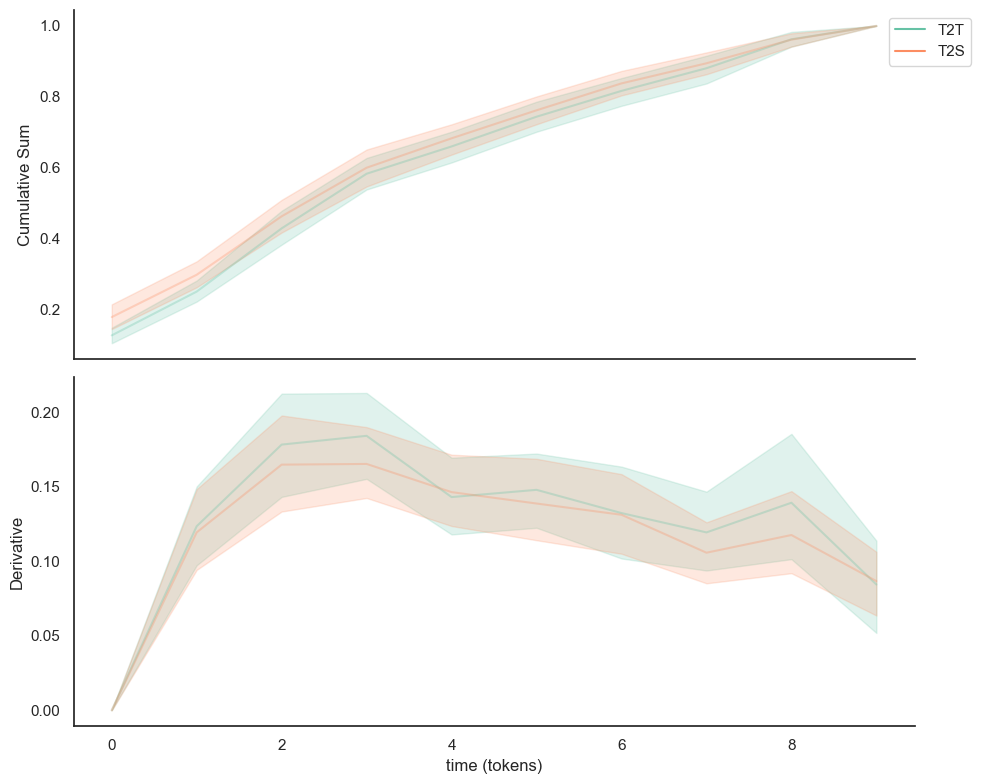

In [63]:
cur_plot_df = plot_df[plot_df["mode"].isin(["T2S", "T2T"])].copy()
cur_plot_df["mode"] = cur_plot_df["mode"].cat.remove_unused_categories()

plot_importance_cumsum_and_derivative(cur_plot_df)
plt.savefig(f"{CHARTS_DIR}/cumulative_shapley_and_derivative_1.png")
plt.show()

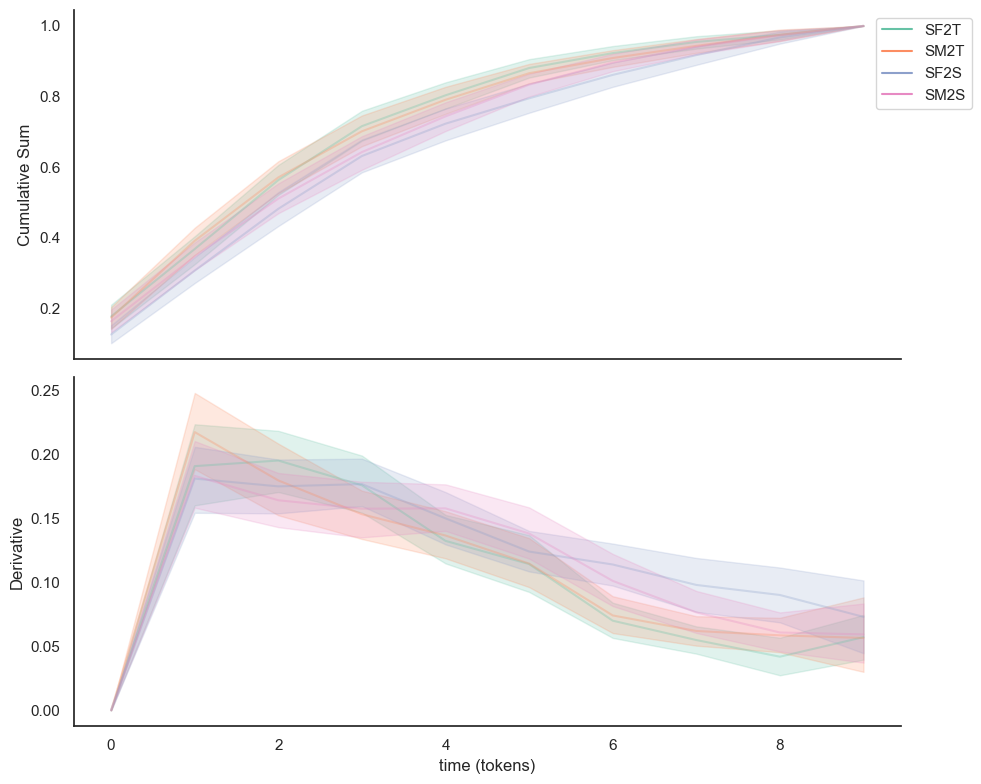

In [64]:
cur_plot_df = plot_df[plot_df["mode"].isin(["SM2S", "SM2T", "SF2S", "SF2T"])].copy()
cur_plot_df["mode"] = cur_plot_df["mode"].cat.remove_unused_categories()

plot_importance_cumsum_and_derivative(cur_plot_df)
plt.savefig(f"{CHARTS_DIR}/cumulative_shapley_and_derivative_1.png")
plt.show()

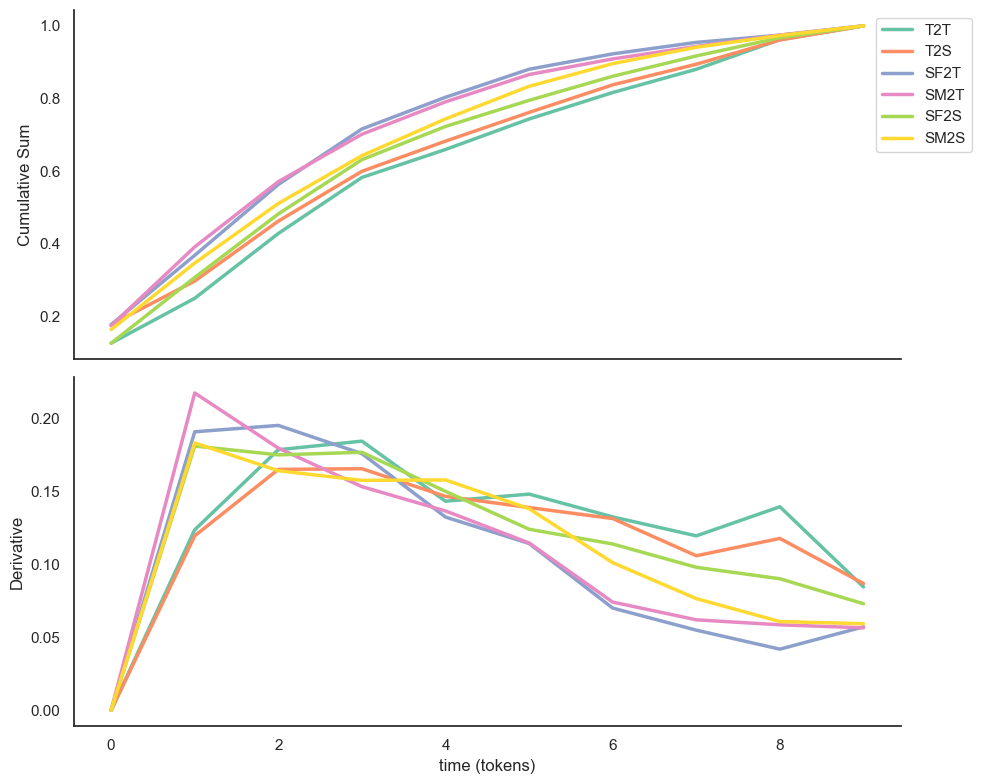

In [65]:
cur_plot_df = plot_df[plot_df["mode"].isin(["T2T", "T2S", "SM2S", "SM2T", "SF2S", "SF2T"])].copy()
cur_plot_df["mode"] = cur_plot_df["mode"].cat.remove_unused_categories()

plot_importance_cumsum_and_derivative(cur_plot_df, errorbar=None, alpha=1.0, linewidth=2.5)
plt.savefig(f"{CHARTS_DIR}/cumulative_shapley_and_derivative_3.png")
plt.show()

## General tests

Does the mean values of Shapley values differ significantly?

In [66]:
results = perform_ttest((all_modes_results_df.groupby(["row_index", "mode"])[SV_COL].mean().unstack(level="mode")))

results.to_csv(f"{STATS_DIR}/mean_ttest_results.csv")

In [67]:
results = results.reset_index()[["Mode_1", "Mode_2", "P_Value", "Significant_Adj"]]

In [68]:
restrict_to = ["T2T", "S2T", "T2S", "S2S"]
results[results["Mode_1"].isin(restrict_to) & results["Mode_2"].isin(restrict_to)]

,Mode_1,Mode_2,P_Value,Significant_Adj
18,T2T,T2S,0.6,False
19,T2T,S2T,<0.01,True
22,T2T,S2S,<0.01,True
25,T2S,S2T,<0.01,True
28,T2S,S2S,<0.01,True
31,S2T,S2S,0.81,False


In [69]:
restrict_to = ["T2*", "S2*", "*2T", "*2S"]
results[results["Mode_1"].isin(restrict_to) & results["Mode_2"].isin(restrict_to)]

,Mode_1,Mode_2,P_Value,Significant_Adj
0,T2*,S2*,<0.01,True
9,*2T,*2S,0.64,False


Does the max values of Shapley values differ significantly?

In [70]:
(all_modes_results_df.groupby(["row_index", "mode"])[SV_COL].max().unstack(level="mode"))

mode,ALL,T2*,S2*,*2T,*2S,T2T,T2S,S2T,SF2T,SM2T,S2S,SF2S,SM2S
row_index,,,,,,,,,,,,,
0,0.347182,0.275398,0.347182,0.347182,0.336012,0.275398,0.188998,0.347182,0.347182,0.189171,0.336012,0.336012,0.191056
1,0.438976,0.421444,0.438976,0.427119,0.438976,0.365177,0.421444,0.427119,0.424390,0.427119,0.438976,0.438976,0.437247
2,0.452906,0.268343,0.452906,0.452906,0.435395,0.268343,0.190448,0.452906,0.452906,0.299880,0.435395,0.374703,0.435395
3,0.477820,0.269089,0.477820,0.477820,0.464812,0.269089,0.243822,0.477820,0.477820,0.297682,0.464812,0.311846,0.464812
4,0.413055,0.367363,0.413055,0.390138,0.413055,0.367363,0.364271,0.390138,0.346774,0.390138,0.413055,0.255252,0.413055
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.437393,0.286614,0.437393,0.437393,0.395506,0.202306,0.286614,0.437393,0.278945,0.437393,0.395506,0.222808,0.395506
96,0.363241,0.363241,0.323647,0.356438,0.363241,0.356438,0.363241,0.305732,0.305732,0.245815,0.323647,0.315778,0.323647
97,0.677128,0.677128,0.333333,0.677128,0.481311,0.677128,0.481311,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333


In [71]:
results = perform_ttest((all_modes_results_df.groupby(["row_index", "mode"])[SV_COL].max().unstack(level="mode")))

results.to_csv(f"{STATS_DIR}/max_ttest_results.csv")

In [72]:
results = results.reset_index()[["Mode_1", "Mode_2", "P_Value", "Significant_Adj"]]

In [73]:
restrict_to = ["T2T", "S2T", "T2S", "S2S"]
results[results["Mode_1"].isin(restrict_to) & results["Mode_2"].isin(restrict_to)]

,Mode_1,Mode_2,P_Value,Significant_Adj
18,T2T,T2S,0.8,False
19,T2T,S2T,<0.01,True
22,T2T,S2S,0.1,False
25,T2S,S2T,<0.01,True
28,T2S,S2S,0.23,False
31,S2T,S2S,<0.01,True


## Entropy

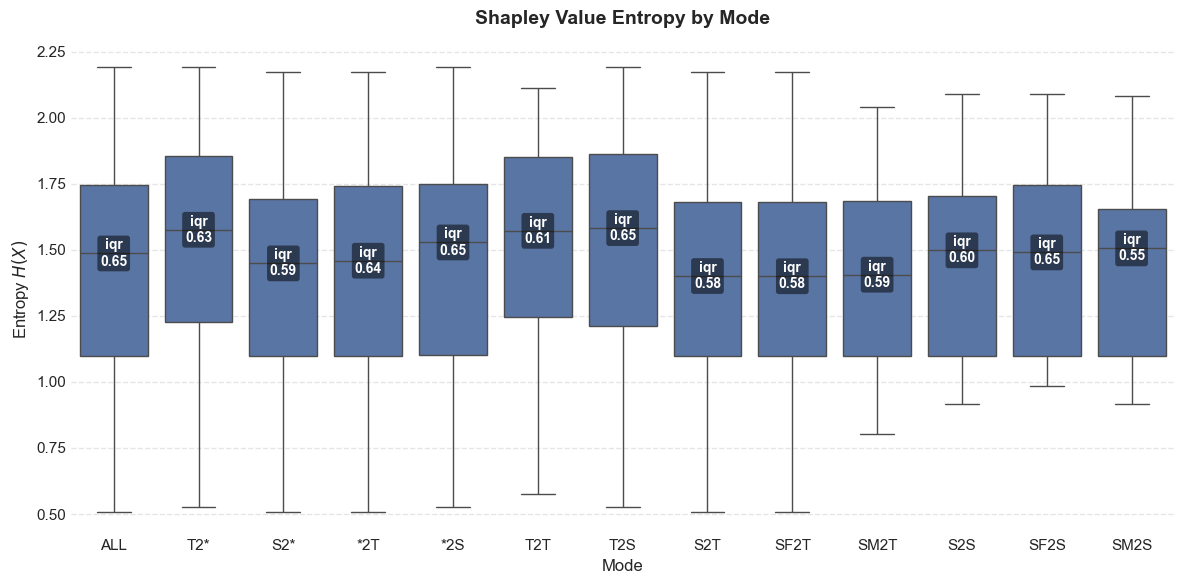

In [74]:
def calculate_entropy(sv_list: list) -> float:
    """Calculate entropy of shapley values."""
    return entropy(np.array(sv_list, dtype=float))


all_modes_combined_df["sv_entropy"] = all_modes_combined_df["sv"].apply(calculate_entropy)
stats = all_modes_combined_df.groupby("mode")["sv_entropy"].agg(
    median="median", iqr=lambda x: x.quantile(0.75) - x.quantile(0.25)
)

plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=all_modes_combined_df, x="mode", y="sv_entropy", showfliers=False)

for i, (m_val, iqr_val) in enumerate(zip(stats["median"], stats["iqr"])):
    if np.isnan(m_val):
        continue
    ax.text(
        i,
        m_val,
        f"iqr\n{iqr_val:.2f}",
        ha="center",
        va="center",
        fontweight="bold",
        size=10,
        color="white",
        bbox={"facecolor": "black", "alpha": 0.5, "edgecolor": "none", "boxstyle": "round,pad=0.2"},
    )

plt.title("Shapley Value Entropy by Mode", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Mode", fontsize=12)
plt.ylabel("Entropy $H(X)$", fontsize=12)
sns.despine(left=True, bottom=True, top=True, right=True)
ax.tick_params(axis="both", which="both", length=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/sv_entropy_by_mode.png")
plt.show()

In [75]:
exploded_position_df = (
    all_modes_combined_df.apply(
        lambda row: [
            {
                "row_index": row["row_index"],
                "mode": row["mode"],
                "token": token,
                "sv": sv,
            }
            for token, sv in zip(row["tokens"], row["sv"])
        ],
        axis=1,
    )
    .explode()
    .apply(pd.Series)
    .reset_index(drop=True)
)

exploded_position_df["token_pos_idx"] = exploded_position_df.groupby(["mode", "row_index"]).cumcount()
exploded_position_df["max_idx"] = exploded_position_df.groupby(["mode", "row_index"])["token_pos_idx"].transform("max")
exploded_position_df.loc[exploded_position_df["max_idx"] == 0, "max_idx"] = 1
exploded_position_df["normalized_position"] = exploded_position_df["token_pos_idx"] / exploded_position_df["max_idx"]

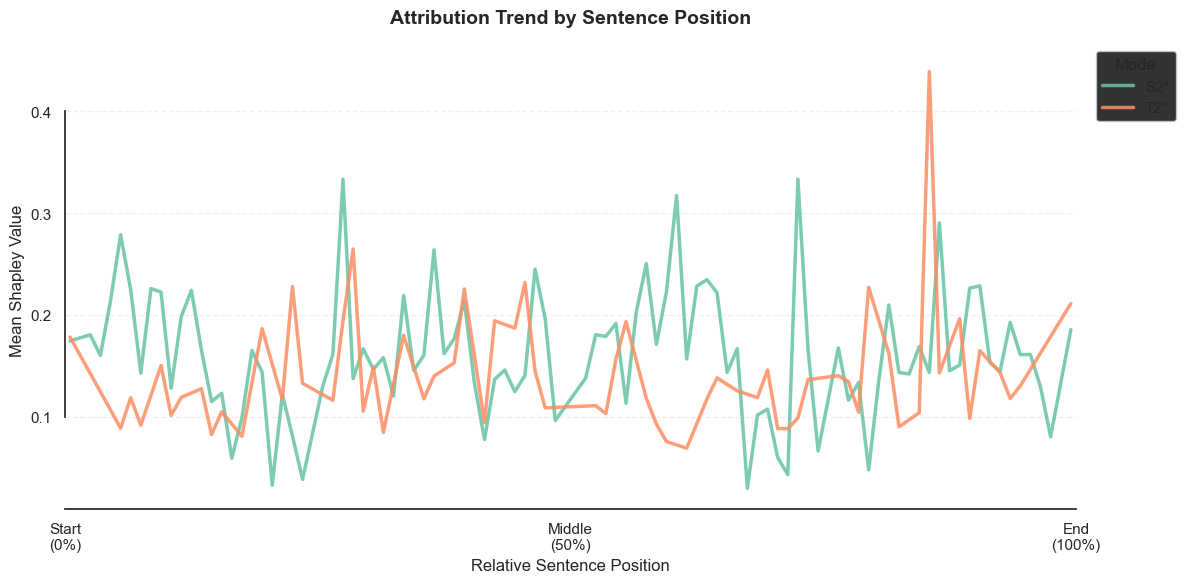

In [76]:
plot_attribution_trend(exploded_position_df[exploded_position_df["mode"].isin(["T2*", "S2*"])], n_bins=100)

plt.savefig(f"{CHARTS_DIR}/positional_bias_smooth_1.png")
plt.show()

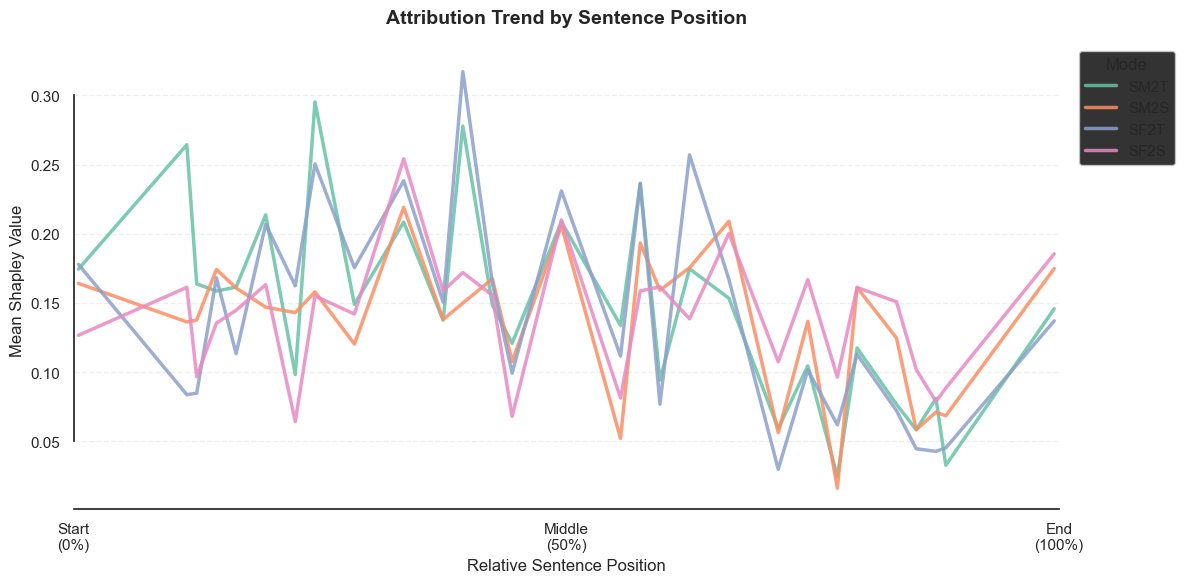

In [77]:
plot_attribution_trend(
    exploded_position_df[exploded_position_df["mode"].isin(["SM2S", "SF2S", "SM2T", "SF2T"])], n_bins=100
)

plt.savefig(f"{CHARTS_DIR}/positional_bias_smooth_2.png")
plt.show()

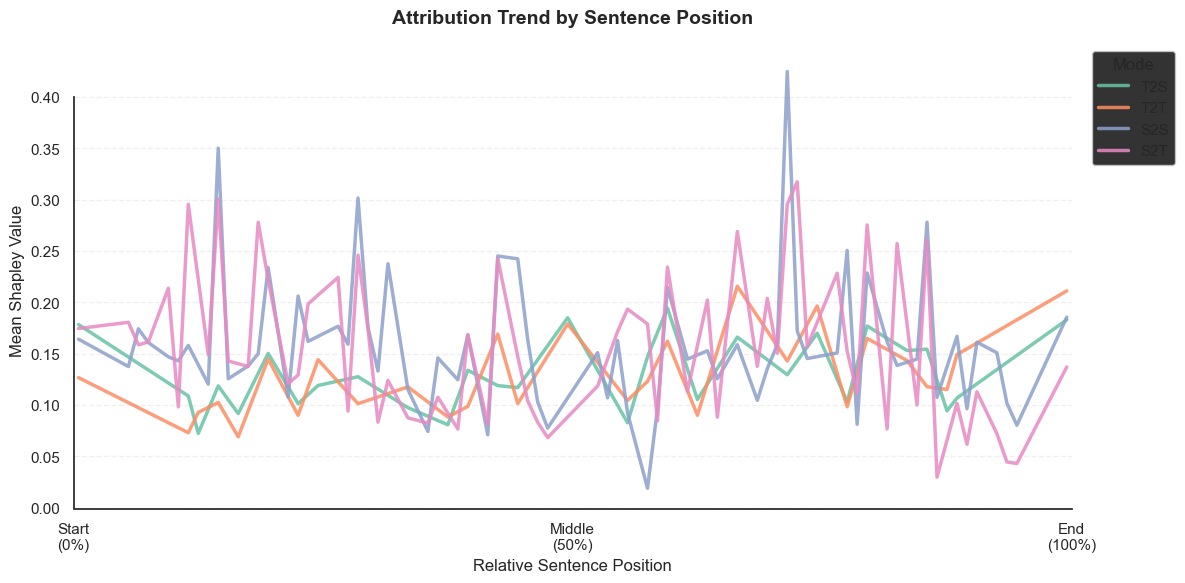

In [78]:
plot_attribution_trend(
    exploded_position_df[exploded_position_df["mode"].isin(["T2T", "T2S", "S2T", "S2S"])], n_bins=100
)

plt.savefig(f"{CHARTS_DIR}/positional_bias_smooth_3.png")
plt.show()